In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import numpy as np

In [3]:
data=[1,2,3,4,5,6,7,8,9,10]
q1=np.quantile(data,0.25)
q2=np.quantile(data,0.5)
q3=np.quantile(data,0.75)
print(q1,q2,q3)

3.25 5.5 7.75


In [4]:
IQR=q3-q1
IQR

np.float64(4.5)

In [5]:
mini=q1-1.5*IQR
mini

np.float64(-3.5)

In [6]:
maxm=q3+1.5*IQR
maxm

np.float64(14.5)

In [7]:
data=np.array([12,-20,1,4,6,-4,20,9,10])
q1=np.quantile(data,0.25)
q2=np.quantile(data,0.5)
q3=np.quantile(data,0.75)
IQR=q3-q1
mini=q1-1.5*IQR
maxm=q3+1.5*IQR
print(q1,q2,q3)
print(IQR,mini,maxm)

1.0 6.0 10.0
9.0 -12.5 23.5


In [8]:
#filtering way 1

In [9]:
filtered = data[(data > mini) & (data<maxm)]
filtered

array([12,  1,  4,  6, -4, 20,  9, 10])

In [10]:
filtered = data[(data > maxm) | (data<mini)]
filtered

array([-20])

In [11]:
NoOutelier = np.where((data > mini) & (data<maxm), "True","False")
NoOutelier

array(['True', 'False', 'True', 'True', 'True', 'True', 'True', 'True',
       'True'], dtype='<U5')

In [12]:
data = np.where(data > maxm, filtered.max(), data)
data = np.where(data < mini, filtered.min(), data)
data

array([ 12, -20,   1,   4,   6,  -4,  20,   9,  10])

In [13]:
employess = {
    "name" : ["Ahmed", "Ali", "Muna", "Reem", "Mohammed"],
    "salary" : [450, 400, 500, 2000, 50]
}
df = pd.DataFrame(employess)
df.head()


,name,salary
0,Ahmed,450
1,Ali,400
2,Muna,500
3,Reem,2000
4,Mohammed,50


In [14]:
#detect the employ with outlayer salary
q1 = np.quantile(df["salary"], 0.25)
q2 = np.quantile(df["salary"], 0.50)  # median
q3 = np.quantile(df["salary"], 0.75)

IQR = q3 - q1
lower = q1 - 1.5 * IQR
upper = q3 + 1.5 * IQR
print( q1,q2,q3)
print( IQR, lower,  upper)

400.0 450.0 500.0
100.0 250.0 650.0


In [15]:
theOutlier = df[(df["salary"] < lower) | (df["salary"] > upper)]
theOutlier

,name,salary
3,Reem,2000
4,Mohammed,50


In [16]:
normalsal = df[(df["salary"] > lower) & (df["salary"] < upper)]
normalsal

,name,salary
0,Ahmed,450
1,Ali,400
2,Muna,500


In [17]:
df["salary"]= np.where((df["salary"]<lower), normalsal["salary"].min(),df["salary"])
df.head()
df["salary"]= np.where((df["salary"] > upper), normalsal["salary"].max(), df["salary"])
df.head()

,name,salary
0,Ahmed,450
1,Ali,400
2,Muna,500
3,Reem,500
4,Mohammed,400


C:\Users\DELL\AppData\Local\Temp\ipykernel_3104\2060900857.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


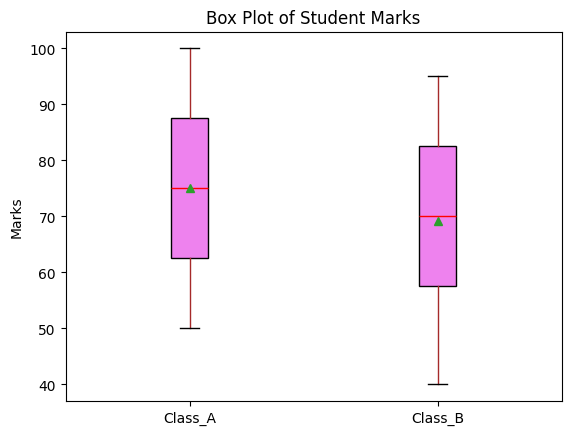

In [19]:
# Create DataFrame
data = {
    "Class_A": [50, 60, 70, 80, 90, 100],
    "Class_B": [40, 55, 65, 75, 85, 95]
}

df = pd.DataFrame(data)

plt.boxplot(
    df.values,                  # data values from DataFrame (each column = one box)
    labels=df.columns,          # names for each box (Class_A, Class_B)
    patch_artist=True,         # fill boxes with color
    showmeans=True,            # show mean value as a marker
    boxprops=dict(facecolor="violet"),  # box color styling
    medianprops=dict(color="red"),         # median line color
    whiskerprops=dict(color="brown"),      # whiskers (lines) color
    capprops=dict(color="black")           # caps (end lines) color
)

plt.title("Box Plot of Student Marks")   # chart title
plt.ylabel("Marks")                      # y-axis label
plt.show()



In [35]:
employess = {
    "name" : ["Ahmed", "Ali", "Muna", "Reem", "Mohammed"],
    "salary" : [450, 400, 500, 2000, 50]
}
df = pd.DataFrame(employess)
df.head()


,name,salary
0,Ahmed,450
1,Ali,400
2,Muna,500
3,Reem,2000
4,Mohammed,50


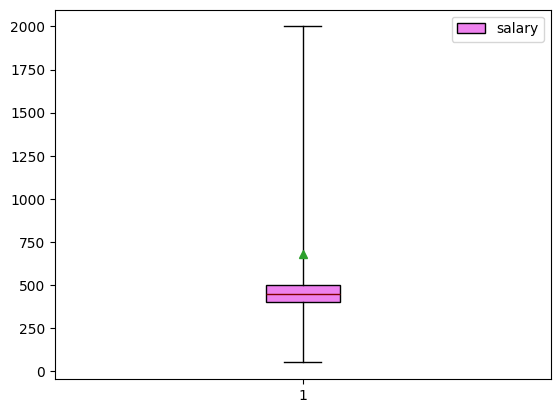

In [44]:
plt.boxplot(df[ "salary"].values,label= "salary",whis=[0,100],
             patch_artist=True,         # fill boxes with color
    showmeans=True,            # show mean value as a marker
    boxprops=dict(facecolor="violet"),  # box color styling
    medianprops=dict(color="maroon"),         
    capprops=dict(color="black")           
)
plt.legend()
plt.show()